Train Shape: (80000, 17)
Test Shape: (20000, 17)

--- Train Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   transaction_id                    80000 non-null  object
 1   customer_id                       80000 non-null  object
 2   transaction_timestamp             80000 non-null  object
 3   transaction_amount                78164 non-null  object
 4   payment_method                    79190 non-null  object
 5   device_type                       79174 non-null  object
 6   location                          79184 non-null  object
 7   merchant_category                 79193 non-null  object
 8   is_international                  80000 non-null  object
 9   transaction_frequency_24h         78608 non-null  object
 10  avg_transaction_amount_7d         78126 non-null  object
 11  failed

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4208\2938917999.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='label', palette='viridis', legend=False)


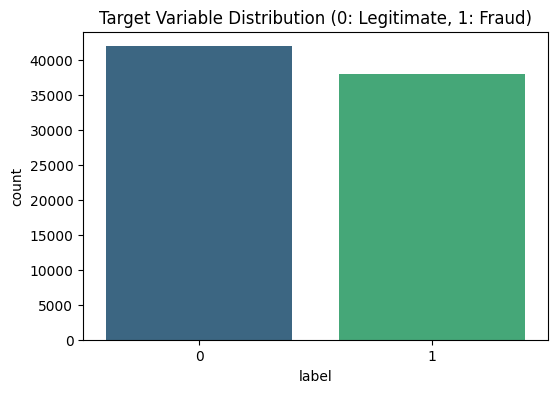

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,unusual_amount_flag,multiple_transactions_short_time,high_risk_device_flag,label
0,T0000429,C18117,2025-04-30 19:56:23.688247,209.35,PayPal,Mobile,Canada,Groceries,true,14,100.5,3,1499,Y,true,N,1
1,T0000802,C12701,2025-04-30 19:56:23.696115,330.37,Google Pay,Mobile,Canada,Electronics,no,9,101.05,0,1683,Y,true,no,0
2,T0001022,C16921,2025-04-30 19:56:23.700517,140.7,PayPal,Tablet,Australia,Travel,FALSE,14,NaN,0,1058,yes,yes,N,1
3,T0001056,C22487,2025-04-30 19:56:23.701177,0.65,PayPal,Desktop,Germany,Travel,N,6,97.23,3,1826,false,0,false,0
4,T0001217,C07940,2025-04-30 19:56:23.704498,230.28,Debit Card,Mobile,India,Electronics,1,1,44.73,1,512,Y,N,Y,1


In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
train_path = 'Dataset/train.xlsx'
test_path = 'Dataset/student_test.xlsx'

df_train = pd.read_excel(train_path)
df_test = pd.read_excel(test_path)

# 2. Basic dataset information
print(f"Train Shape: {df_train.shape}")
print(f"Test Shape: {df_test.shape}\n")

print("--- Train Data Info ---")
df_train.info()

print("\n--- Missing Values in Train Data ---")
missing_vals = df_train.isnull().sum()
print(missing_vals[missing_vals > 0])

# 3. Check Class Imbalance
print("\n--- Target Class Distribution (label) ---")
print(df_train['label'].value_counts())
print("\nPercentage:\n", df_train['label'].value_counts(normalize=True) * 100)

# 4. Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='label', palette='viridis', legend=False)
plt.title('Target Variable Distribution (0: Legitimate, 1: Fraud)')
plt.show()

# 5. Show first few rows
display(df_train.head())

In [126]:
import numpy as np

def clean_data(df):
    df = df.copy()
    
    # 1. Convert Timestamp to Datetime
    if 'transaction_timestamp' in df.columns:
        df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], errors='coerce')
    
    # 2. Fix Boolean/Flag columns (Standardize to 0 / 1)
    bool_cols = ['is_international', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']
    bool_mapping = {
        'y': 1, 'yes': 1, 'true': 1, '1': 1, '1.0': 1,
        'n': 0, 'no': 0, 'false': 0, '0': 0, '0.0': 0
    }
    
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip().map(bool_mapping)
    
    # 3. Clean Numeric columns (remove commas, convert to float)
    num_cols = ['transaction_amount', 'transaction_frequency_24h', 
                'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days']
    
    for col in num_cols:
        if col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True) # Keep only numbers and decimals
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    # 4. Clean Categorical columns (lowercase and strip spaces to fix typos)
    cat_cols = ['payment_method', 'device_type', 'location', 'merchant_category']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip()
            df[col] = df[col].replace('nan', np.nan) # Convert string 'nan' back to real NaN
            
    return df

# Apply the cleaning function to both datasets
df_train_cleaned = clean_data(df_train)
df_test_cleaned = clean_data(df_test)

# Verify the changes
print("--- Cleaned Train Data Info ---")
df_train_cleaned.info()
display(df_train_cleaned.head())

--- Cleaned Train Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   transaction_id                    80000 non-null  object        
 1   customer_id                       80000 non-null  object        
 2   transaction_timestamp             80000 non-null  datetime64[ns]
 3   transaction_amount                77621 non-null  float64       
 4   payment_method                    79190 non-null  object        
 5   device_type                       79174 non-null  object        
 6   location                          79184 non-null  object        
 7   merchant_category                 79193 non-null  object        
 8   is_international                  80000 non-null  int64         
 9   transaction_frequency_24h         78173 non-null  float64       
 10  avg_transactio

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,unusual_amount_flag,multiple_transactions_short_time,high_risk_device_flag,label
0,T0000429,C18117,2025-04-30 19:56:23.688247,209.35,paypal,mobile,canada,groceries,1,14.0,100.50,3.0,1499.0,1,1,0,1
1,T0000802,C12701,2025-04-30 19:56:23.696115,330.37,google pay,mobile,canada,electronics,0,9.0,101.05,0.0,1683.0,1,1,0,0
2,T0001022,C16921,2025-04-30 19:56:23.700517,140.70,paypal,tablet,australia,travel,0,14.0,NaN,0.0,1058.0,1,1,0,1
3,T0001056,C22487,2025-04-30 19:56:23.701177,0.65,paypal,desktop,germany,travel,0,6.0,97.23,3.0,1826.0,0,0,0,0
4,T0001217,C07940,2025-04-30 19:56:23.704498,230.28,debit card,mobile,india,electronics,1,1.0,44.73,1.0,512.0,1,0,1,1


In [127]:
# 6. Inspect unique values to find typos and dirty data
for col in df_train_cleaned.columns:
    unique_vals = df_train_cleaned[col].dropna().unique()
    n_unique = len(unique_vals)
    
    print(f"--- {col} ---")
    print(f"Unique Count: {n_unique}")
    
    # Show all values if cardinality is low (e.g., categories, flags)
    if n_unique < 50:
        print(f"Values: {unique_vals}\n")
    else:
        # Show a sample for high cardinality columns (IDs, amounts, timestamps)
        print(f"Sample Values: {unique_vals[:5]}\n")


--- transaction_id ---
Unique Count: 80000
Sample Values: ['T0000429' 'T0000802' 'T0001022' 'T0001056' 'T0001217']

--- customer_id ---
Unique Count: 27937
Sample Values: ['C18117' 'C12701' 'C16921' 'C22487' 'C07940']

--- transaction_timestamp ---
Unique Count: 80000
Sample Values: <DatetimeArray>
['2025-04-30 19:56:23.688247', '2025-04-30 19:56:23.696115',
 '2025-04-30 19:56:23.700517', '2025-04-30 19:56:23.701177',
 '2025-04-30 19:56:23.704498']
Length: 5, dtype: datetime64[ns]

--- transaction_amount ---
Unique Count: 29730
Sample Values: [209.35 330.37 140.7    0.65 230.28]

--- payment_method ---
Unique Count: 22
Values: ['paypal' 'google pay' 'debit card' 'apple pay' 'credit card'
 'gift voucher' 'manual invoice' 'paypall' 'pay pal' 'applepay'
 'debiit card' 'pay_pal' 'credt card' 'google_pay' 'debit_card'
 'creditcard' 'debitcard' 'googlepay' 'apple_pay' 'gooogle pay'
 'credit_card' 'crypto wallet']

--- device_type ---
Unique Count: 13
Values: ['mobile' 'tablet' 'desktop' 'des

In [128]:
# 1. Dictionary for fixing typos
typo_maps = {
    'payment_method': {
        'paypall': 'paypal', 'pay pal': 'paypal', 'pay_pal': 'paypal',
        'google_pay': 'google pay', 'googlepay': 'google pay', 'gooogle pay': 'google pay',
        'applepay': 'apple pay', 'apple_pay': 'apple pay',
        'debiit card': 'debit card', 'debit_card': 'debit card', 'debitcard': 'debit card',
        'credt card': 'credit card', 'creditcard': 'credit card', 'credit_card': 'credit card'
    },
    'device_type': {
        'desktop_pc': 'desktop', 'desk top': 'desktop', 'desktp': 'desktop',
        'tabelt': 'tablet', 'tab let': 'tablet', 'tablet_device': 'tablet',
        'moblie': 'mobile'
    },
    'location': {
        'austraila': 'australia', 'au': 'australia',
        'untied kingdom': 'uk', 'united kingdom': 'uk', 'u.k.': 'uk',
        'in': 'india', 'indai': 'india',
        'us': 'usa', 'u.s.a.': 'usa',
        'canadaa': 'canada', 'ca': 'canada',
        'atlantis': 'anomaly', 'mars colony': 'anomaly', 'unknown region': 'unknown'
    },
    'merchant_category': {
        'fashoin': 'fashion', 'fashon': 'fashion',
        'groceriez': 'groceries', 'grocery': 'groceries',
        'electornics': 'electronics', 'electronic': 'electronics',
        'gameing': 'gaming',
        'travels': 'travel',
        'restaraunts': 'restaurants'
    }
}

# 2. Apply typos fix
for col, mapping in typo_maps.items():
    df_train_cleaned[col] = df_train_cleaned[col].replace(mapping)
    df_test_cleaned[col] = df_test_cleaned[col].replace(mapping)

# 3. Handle Missing Values (Prevent Data Leakage: Use Train stats for both)
cat_cols = ['payment_method', 'device_type', 'location', 'merchant_category']
for col in cat_cols:
    df_train_cleaned[col] = df_train_cleaned[col].fillna('unknown')
    df_test_cleaned[col] = df_test_cleaned[col].fillna('unknown')

num_cols = ['transaction_amount', 'transaction_frequency_24h', 
            'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days']
train_medians = df_train_cleaned[num_cols].median()

df_train_cleaned[num_cols] = df_train_cleaned[num_cols].fillna(train_medians)
df_test_cleaned[num_cols] = df_test_cleaned[num_cols].fillna(train_medians)

print("Train Missing Values:\n", df_train_cleaned.isnull().sum().sum())
print("Test Missing Values:\n", df_test_cleaned.isnull().sum().sum())


Train Missing Values:
 0
Test Missing Values:
 0


In [129]:

import re

def deep_clean_strings(df):
    df = df.copy()
    str_cols = df.select_dtypes(include=['object']).columns
    
    for col in str_cols:
        df[col] = df[col].astype(str).str.lower()
        df[col] = df[col].replace(r'[\n\t\r]', ' ', regex=True)
        df[col] = df[col].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
        df[col] = df[col].replace({'nan': 'unknown', '': 'unknown', 'none': 'unknown'})
        
    return df

df_train_cleaned = deep_clean_strings(df_train_cleaned)
df_test_cleaned = deep_clean_strings(df_test_cleaned)

for col, mapping in typo_maps.items():
    if col in df_train_cleaned.columns:
        df_train_cleaned[col] = df_train_cleaned[col].replace(mapping)
        df_test_cleaned[col] = df_test_cleaned[col].replace(mapping)

print("--- Final Unique Categorical Values ---")
for col in cat_cols:
    print(f"\n{col}: {df_train_cleaned[col].unique()}")


--- Final Unique Categorical Values ---

payment_method: ['paypal' 'google pay' 'debit card' 'apple pay' 'credit card'
 'gift voucher' 'manual invoice' 'unknown' 'crypto wallet']

device_type: ['mobile' 'tablet' 'desktop' 'unknown' 'smart tv' 'wearable' 'console']

location: ['canada' 'australia' 'germany' 'india' 'unknown' 'usa' 'anomaly' 'uk']

merchant_category: ['groceries' 'electronics' 'travel' 'gaming' 'luxury' 'fashion' 'unknown'
 'antiques' 'private seller' 'collectibles' 'restaurants']


In [130]:
def final_sanity_check(df, dataset_name="Dataset"):
    print(f"================ {dataset_name} SANITY CHECK ================")
    
    total_missing = df.isnull().sum().sum()
    print(f"\n[1] Total Missing Values: {total_missing}")
    if total_missing > 0:
        print(df.isnull().sum()[df.isnull().sum() > 0])
        
    print("\n[2] Data Types:")
    print(df.dtypes)
    
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    if len(num_cols) > 0:
        print("\n[3] Numeric Statistics (Min/Max/Mean):")
        display(df[num_cols].describe().T[['min', 'mean', 'max']])

final_sanity_check(df_train_cleaned, "TRAIN")
final_sanity_check(df_test_cleaned, "TEST")


================ TRAIN SANITY CHECK ================

[1] Total Missing Values: 0

[2] Data Types:
transaction_id                              object
customer_id                                 object
transaction_timestamp               datetime64[ns]
transaction_amount                         float64
payment_method                              object
device_type                                 object
location                                    object
merchant_category                           object
is_international                             int64
transaction_frequency_24h                  float64
avg_transaction_amount_7d                  float64
failed_transaction_count_24h               float64
account_age_days                           float64
unusual_amount_flag                          int64
multiple_transactions_short_time             int64
high_risk_device_flag                        int64
label                                        int64
dtype: object

[3] Numeric Statist

,min,mean,max
transaction_amount,0.0,235.280721,24994.30
is_international,0.0,0.498400,1.00
transaction_frequency_24h,1.0,8.558087,249.00
avg_transaction_amount_7d,1.0,193.500920,17985.81
failed_transaction_count_24h,0.0,2.472187,119.00
account_age_days,10.0,1095.125550,24870.00
unusual_amount_flag,0.0,0.228950,1.00
multiple_transactions_short_time,0.0,0.426463,1.00
high_risk_device_flag,0.0,0.100212,1.00
label,0.0,0.475662,1.00


================ TEST SANITY CHECK ================

[1] Total Missing Values: 0

[2] Data Types:
id                                           int64
transaction_id                              object
customer_id                                 object
transaction_timestamp               datetime64[ns]
transaction_amount                         float64
payment_method                              object
device_type                                 object
location                                    object
merchant_category                           object
is_international                             int64
transaction_frequency_24h                  float64
avg_transaction_amount_7d                  float64
failed_transaction_count_24h               float64
account_age_days                           float64
unusual_amount_flag                          int64
multiple_transactions_short_time             int64
high_risk_device_flag                        int64
dtype: object

[3] Numeric Statisti

,min,mean,max
id,0.0,9999.500000,19999.00
transaction_amount,0.0,233.377930,24952.97
is_international,0.0,0.496450,1.00
transaction_frequency_24h,1.0,8.638750,249.00
avg_transaction_amount_7d,1.0,193.100967,17943.91
failed_transaction_count_24h,0.0,2.523000,119.00
account_age_days,10.0,1084.663250,24743.00
unusual_amount_flag,0.0,0.231850,1.00
multiple_transactions_short_time,0.0,0.429350,1.00
high_risk_device_flag,0.0,0.103950,1.00


In [131]:
import re

def comprehensive_validation(df, dataset_name="Dataset"):
    print(f"=== Validation Report: {dataset_name} ===")
    invalid_counts = {}
    
    invalid_counts['invalid_transaction_id'] = (~df['transaction_id'].astype(str).str.match(r'^t\d+$', flags=re.IGNORECASE)).sum()
    invalid_counts['invalid_customer_id'] = (~df['customer_id'].astype(str).str.match(r'^c\d+$', flags=re.IGNORECASE)).sum()
    invalid_counts['zero_or_negative_amount'] = (df['transaction_amount'] <= 0).sum()
    invalid_counts['negative_avg_amount_7d'] = (df['avg_transaction_amount_7d'] < 0).sum()
    invalid_counts['negative_frequency'] = (df['transaction_frequency_24h'] < 0).sum()
    invalid_counts['negative_failed_count'] = (df['failed_transaction_count_24h'] < 0).sum()
    invalid_counts['negative_account_age'] = (df['account_age_days'] < 0).sum()
    
    binary_cols = ['is_international', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']
    for col in binary_cols:
        if col in df.columns:
            invalid_counts[f'invalid_binary_{col}'] = (~df[col].isin([0, 1])).sum()
        
    invalid_counts['invalid_timestamp'] = df['transaction_timestamp'].isna().sum()

    has_errors = False
    for check_name, count in invalid_counts.items():
        if count > 0:
            print(f"❌ {check_name}: {count} invalid rows")
            has_errors = True
            
    if not has_errors:
        print("✅ All validation checks passed! No semantic or syntax errors found.")
    print("-" * 40)

comprehensive_validation(df_train_cleaned, "TRAIN")
comprehensive_validation(df_test_cleaned, "TEST")


=== Validation Report: TRAIN ===
❌ zero_or_negative_amount: 3 invalid rows
----------------------------------------
=== Validation Report: TEST ===
❌ zero_or_negative_amount: 1 invalid rows
----------------------------------------


In [132]:
# 1. Calculate the median of VALID amounts in the TRAIN set
valid_median_amount = df_train_cleaned[df_train_cleaned['transaction_amount'] > 0]['transaction_amount'].median()

# 2. Replace zero or negative amounts with this valid median
df_train_cleaned.loc[df_train_cleaned['transaction_amount'] <= 0, 'transaction_amount'] = valid_median_amount
df_test_cleaned.loc[df_test_cleaned['transaction_amount'] <= 0, 'transaction_amount'] = valid_median_amount

# 3. Re-run validation to confirm the fix
comprehensive_validation(df_train_cleaned, "TRAIN (After Fix)")
comprehensive_validation(df_test_cleaned, "TEST (After Fix)")

=== Validation Report: TRAIN (After Fix) ===
✅ All validation checks passed! No semantic or syntax errors found.
----------------------------------------
=== Validation Report: TEST (After Fix) ===
✅ All validation checks passed! No semantic or syntax errors found.
----------------------------------------


In [133]:

from sklearn.preprocessing import OrdinalEncoder

# ==========================================
# FEATURE ENGINEERING & FINAL PREPARATION
# ==========================================
def engineer_features(df):
    df = df.copy()
    
    # 1. Time-based Features
    df['hour'] = df['transaction_timestamp'].dt.hour
    df['day_of_week'] = df['transaction_timestamp'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_night_transaction'] = ((df['hour'] < 6) | (df['hour'] > 22)).astype(int)
    
    # 2. Financial & Ratio Features
    df['amount_to_avg_ratio'] = df['transaction_amount'] / (df['avg_transaction_amount_7d'] + 1e-5)
    
    # 3. Risk Features
    df['freq_to_age_ratio'] = df['transaction_frequency_24h'] / (df['account_age_days'] + 1e-5)
    
    return df

print("⚙️ Applying Feature Engineering...")
df_train_fe = engineer_features(df_train_cleaned)
df_test_fe = engineer_features(df_test_cleaned)

# Drop raw IDs and dates
cols_to_drop = ['transaction_id', 'customer_id', 'transaction_timestamp']
if 'id' in df_test_fe.columns:
    test_ids = df_test_fe['id'].copy()
    cols_to_drop.append('id')

X_train_full = df_train_fe.drop(columns=[c for c in cols_to_drop if c in df_train_fe.columns] + ['label'])
y_train_full = df_train_fe['label']
X_test_full = df_test_fe.drop(columns=[c for c in cols_to_drop if c in df_test_fe.columns])

# Encode Categorical Variables
cat_cols = ['payment_method', 'device_type', 'location', 'merchant_category']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_full[cat_cols] = encoder.fit_transform(X_train_full[cat_cols])
X_test_full[cat_cols] = encoder.transform(X_test_full[cat_cols])

print(f"✅ Final Train Shape for modeling: {X_train_full.shape}")


⚙️ Applying Feature Engineering...
✅ Final Train Shape for modeling: (80000, 19)


In [134]:
from sklearn.model_selection import RandomizedSearchCV

print("⚙️ در حال تیونینگ مدل‌ها (Hyperparameter Tuning)...")
print("⏳ (این مرحله چون چندین بار مدل‌ها رو با تنظیمات مختلف آموزش میده ممکنه ۵ تا ۱۰ دقیقه طول بکشه)")


SEED = 897

# 1. تعریف محدوده‌های منطقی برای تنظیمات (کمی بالا و پایین کردن)
param_grids = {
    'RF': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 8, 12],               # محدود کردن شدید عمق درخت
            'min_samples_split': [10, 20, 50],     # حداقل داده برای انشعاب
            'min_samples_leaf': [5, 10, 20],       # حداقل داده برای تصمیم‌گیری نهایی
            'max_features': ['sqrt', 'log2'],      # استفاده از بخشی از ویژگی‌ها در هر قدم
            'max_samples': [0.7, 0.8, 0.85]        # هر درخت فقط ۷۰ تا ۸۵ درصد دیتا رو می‌بینه
        }
    },
    'XGB': {
        'model': XGBClassifier(eval_metric='logloss', random_state=SEED, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.05, 0.1, 0.2],     # نرخ یادگیری
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 0.9, 1.0]           # جلوگیری از حفظ کردن دیتا
        }
    },
    'HGB': {
        'model': HistGradientBoostingClassifier(random_state=SEED),
        'params': {
            'max_iter': [100, 200, 300],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [None, 10, 20],
            'l2_regularization': [0.0, 0.1, 1.0]   # جریمه برای جلوگیری از Overfit
        }
    }
}

best_tuned_models = {}

# 2. جستجو برای یافتن بهترین تنظیمات با n_iter=10 (بررسی 10 حالت تصادفی برای سرعت مناسب)
for name, config in param_grids.items():
    print(f"\n🔍 در حال جستجوی بهترین تنظیمات برای {name}...")
    search = RandomizedSearchCV(
        config['model'], 
        param_distributions=config['params'], 
        n_iter=10, 
        scoring='f1', 
        cv=3, 
        random_state=42,
        n_jobs=-1
    )
    # تیونینگ روی کل دیتای ترین انجام میشه تا بهترین مدل رو تحویل بده
    search.fit(X_train_full, y_train_full)
    best_tuned_models[name] = search.best_estimator_
    
    print(f"✅ بهترین تنظیمات پیدا شده برای {name}: {search.best_params_}")
    print(f"🎯 بهترین نمره F1 در اعتبارسنجی متقاطع (CV): {search.best_score_:.4f}")


⚙️ در حال تیونینگ مدل‌ها (Hyperparameter Tuning)...
⏳ (این مرحله چون چندین بار مدل‌ها رو با تنظیمات مختلف آموزش میده ممکنه ۵ تا ۱۰ دقیقه طول بکشه)

🔍 در حال جستجوی بهترین تنظیمات برای RF...
✅ بهترین تنظیمات پیدا شده برای RF: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_samples': 0.85, 'max_features': 'sqrt', 'max_depth': 12}
🎯 بهترین نمره F1 در اعتبارسنجی متقاطع (CV): 0.7720

🔍 در حال جستجوی بهترین تنظیمات برای XGB...
✅ بهترین تنظیمات پیدا شده برای XGB: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
🎯 بهترین نمره F1 در اعتبارسنجی متقاطع (CV): 0.7823

🔍 در حال جستجوی بهترین تنظیمات برای HGB...
✅ بهترین تنظیمات پیدا شده برای HGB: {'max_iter': 100, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 0.0}
🎯 بهترین نمره F1 در اعتبارسنجی متقاطع (CV): 0.7814


In [135]:


import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

print("📊 در حال ارزیابی مدل‌های تکی تیون‌شده روی داده‌های Validation...")

# 1. ارزیابی و رسم جدول مقایسه برای مدل‌های تیون‌شده
results_tuned = []
for name, tuned_model in best_tuned_models.items():
    # گرفتن احتمالات از مدل تیون‌شده
    y_val_prob = tuned_model.predict_proba(X_val_v)[:, 1]
    
    best_thresh, best_f1 = 0.5, 0
    for thresh in np.arange(0.1, 0.9, 0.05):
        f1 = f1_score(y_val_v, (y_val_prob >= thresh).astype(int))
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
            
    y_pred = (y_val_prob >= best_thresh).astype(int)
    
    results_tuned.append({
        'Model': f"TUNED {name}",
        'Best Threshold': round(best_thresh, 2),
        'F1 Score': round(f1_score(y_val_v, y_pred), 4),
        'Accuracy': round(accuracy_score(y_val_v, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_val_v, y_val_prob), 4)
    })

# نمایش جدول
display(pd.DataFrame(results_tuned).sort_values(by='F1 Score', ascending=False))

print("\n📁 در حال ساخت فایل‌های CSV برای مدل‌های تکی تیون‌شده...")

# 2. ساخت پوشه خروجی و ذخیره فایل‌های CSV برای دیتای Test
os.makedirs('output', exist_ok=True)
thresholds = np.arange(0.15, 0.46, 0.02)

for model_name, tuned_model in best_tuned_models.items():
    y_test_prob = tuned_model.predict_proba(X_test_full)[:, 1]
    
    for thresh in thresholds:
        thresh_rounded = round(thresh, 2)
        y_test_pred = (y_test_prob >= thresh_rounded).astype(int)
        
        filename = f'sub_TUNED_{model_name}_th_{thresh_rounded:.2f}.csv'
        filepath = os.path.join('output', filename)
        
        pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filepath, index=False)
        print(f"✅ Saved: {filepath}")

print("\n🎉 تمام فایل‌های تکی تیون‌شده در پوشه 'output' ذخیره شدند!")

📊 در حال ارزیابی مدل‌های تکی تیون‌شده روی داده‌های Validation...


,Model,Best Threshold,F1 Score,Accuracy,ROC-AUC
0,TUNED RF,0.45,0.8339,0.8169,0.9365
1,TUNED XGB,0.35,0.8205,0.7927,0.9175
2,TUNED HGB,0.45,0.8205,0.7944,0.9241



📁 در حال ساخت فایل‌های CSV برای مدل‌های تکی تیون‌شده...
✅ Saved: output\sub_TUNED_RF_th_0.15.csv
✅ Saved: output\sub_TUNED_RF_th_0.17.csv
✅ Saved: output\sub_TUNED_RF_th_0.19.csv
✅ Saved: output\sub_TUNED_RF_th_0.21.csv
✅ Saved: output\sub_TUNED_RF_th_0.23.csv
✅ Saved: output\sub_TUNED_RF_th_0.25.csv
✅ Saved: output\sub_TUNED_RF_th_0.27.csv
✅ Saved: output\sub_TUNED_RF_th_0.29.csv
✅ Saved: output\sub_TUNED_RF_th_0.31.csv
✅ Saved: output\sub_TUNED_RF_th_0.33.csv
✅ Saved: output\sub_TUNED_RF_th_0.35.csv
✅ Saved: output\sub_TUNED_RF_th_0.37.csv
✅ Saved: output\sub_TUNED_RF_th_0.39.csv
✅ Saved: output\sub_TUNED_RF_th_0.41.csv
✅ Saved: output\sub_TUNED_RF_th_0.43.csv
✅ Saved: output\sub_TUNED_RF_th_0.45.csv
✅ Saved: output\sub_TUNED_XGB_th_0.15.csv
✅ Saved: output\sub_TUNED_XGB_th_0.17.csv
✅ Saved: output\sub_TUNED_XGB_th_0.19.csv
✅ Saved: output\sub_TUNED_XGB_th_0.21.csv
✅ Saved: output\sub_TUNED_XGB_th_0.23.csv
✅ Saved: output\sub_TUNED_XGB_th_0.25.csv
✅ Saved: output\sub_TUNED_XGB_th_0.

In [136]:
import os
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("⚙️ در حال ساخت Stacking نهایی با استفاده از مدل‌های تیون‌شده...")

# اطمینان از وجود پوشه output
os.makedirs('output', exist_ok=True)

# استفاده از همون مدل‌هایی که توی مرحله اول بهینه‌ترین تنظیماتشون پیدا شد
base_models = [
    ('rf', best_tuned_models['RF']),
    ('xgb', best_tuned_models['XGB']),
    ('hgb', best_tuned_models['HGB'])
]

# Logistic Regression برای تصمیم‌گیری نهایی بین رای ۳ تا مدل
meta_model = LogisticRegression()

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train_full, y_train_full)
y_test_prob_stack = stacking_clf.predict_proba(X_test_full)[:, 1]

# آستانه‌های محتمل برای Stacking
stack_thresholds = [0.15, 0.17, 0.23, 0.28, 0.31, 0.33]

for thresh in stack_thresholds:
    y_test_pred = (y_test_prob_stack >= thresh).astype(int)
    
    # ذخیره در پوشه output
    filename = f'Final_TUNED_Stacking_th_{thresh:.2f}.csv'
    filepath = os.path.join('output', filename)
    
    pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filepath, index=False)
    print(f"📁 ذخیره شد: {filepath}")

print("\n🎉 فایل‌های Stacking در پوشه 'output' ساخته شدند!")

⚙️ در حال ساخت Stacking نهایی با استفاده از مدل‌های تیون‌شده...
📁 ذخیره شد: output\Final_TUNED_Stacking_th_0.15.csv
📁 ذخیره شد: output\Final_TUNED_Stacking_th_0.17.csv
📁 ذخیره شد: output\Final_TUNED_Stacking_th_0.23.csv
📁 ذخیره شد: output\Final_TUNED_Stacking_th_0.28.csv
📁 ذخیره شد: output\Final_TUNED_Stacking_th_0.31.csv
📁 ذخیره شد: output\Final_TUNED_Stacking_th_0.33.csv

🎉 فایل‌های Stacking در پوشه 'output' ساخته شدند!


In [ ]:
شسیبشب
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("⚙️ در حال ساخت Stacking نهایی با استفاده از مدل‌های تیون‌شده...")

# استفاده از همون مدل‌هایی که توی مرحله اول بهینه‌ترین تنظیماتشون پیدا شد
base_models = [
    ('rf', best_tuned_models['RF']),
    ('xgb', best_tuned_models['XGB']),
    ('hgb', best_tuned_models['HGB'])
]

# Logistic Regression برای تصمیم‌گیری نهایی بین رای ۳ تا مدل
meta_model = LogisticRegression()

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train_full, y_train_full)
y_test_prob_stack = stacking_clf.predict_proba(X_test_full)[:, 1]

# آستانه‌های محتمل برای Stacking (معمولاً اعداد پایین‌تر برای F1 جواب میدن)
stack_thresholds = [0.25, 0.30, 0.32, 0.35, 0.38, 0.40]

for thresh in stack_thresholds:
    y_test_pred = (y_test_prob_stack >= thresh).astype(int)
    filename = f'Final_TUNED_Stacking_th_{thresh:.2f}.csv'
    pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filename, index=False)
    print(f"📁 ذخیره شد: {filename}")

print("\n🎉 فایل‌های Stacking با مدل‌های Tune شده ساخته شدند!")

NameError: name 'شسیبشب' is not defined

: 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, matthews_corrcoef, cohen_kappa_score)

# Model Validation (to check metrics before generating CSVs)
X_train_v, X_val_v, y_train_v, y_val_v = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

models = {
    'RF': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGB': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    'HGB': HistGradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    print(f"Evaluating {name}...")
    model.fit(X_train_v, y_train_v)
    y_val_prob = model.predict_proba(X_val_v)[:, 1]
    
    best_thresh, best_f1 = 0.5, 0
    for thresh in np.arange(0.1, 0.9, 0.05):
        f1 = f1_score(y_val_v, (y_val_prob >= thresh).astype(int))
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
            
    y_pred = (y_val_prob >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_v, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    results.append({
        'Model': name,
        'Best Threshold': round(best_thresh, 2),
        'F1 Score': round(f1_score(y_val_v, y_pred), 4),
        'Accuracy': round(accuracy_score(y_val_v, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_val_v, y_val_prob), 4)
    })

display(pd.DataFrame(results).sort_values(by='F1 Score', ascending=False))


NameError: name 'شسیبشسب' is not defined

In [ ]:
thresholds = np.arange(0.20, 0.55, 0.05)

for model_name, model in models.items():
    print(f"\n--- Training {model_name} on Full Data ---")
    model.fit(X_train_full, y_train_full)
    y_test_prob = model.predict_proba(X_test_full)[:, 1]
    
    for thresh in thresholds:
        thresh_rounded = round(thresh, 2)
        y_test_pred = (y_test_prob >= thresh_rounded).astype(int)
        
        filename = f'sub_{model_name}_th_{thresh_rounded:.2f}.csv'
        pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filename, index=False)
        print(f"✅ Saved: {filename}")

print("\n🎉 All individual submission files generated successfully!")



--- Training RF on Full Data ---
✅ Saved: sub_RF_th_0.20.csv
✅ Saved: sub_RF_th_0.25.csv
✅ Saved: sub_RF_th_0.30.csv
✅ Saved: sub_RF_th_0.35.csv
✅ Saved: sub_RF_th_0.40.csv
✅ Saved: sub_RF_th_0.45.csv
✅ Saved: sub_RF_th_0.50.csv

--- Training XGB on Full Data ---
✅ Saved: sub_XGB_th_0.20.csv
✅ Saved: sub_XGB_th_0.25.csv
✅ Saved: sub_XGB_th_0.30.csv
✅ Saved: sub_XGB_th_0.35.csv
✅ Saved: sub_XGB_th_0.40.csv
✅ Saved: sub_XGB_th_0.45.csv
✅ Saved: sub_XGB_th_0.50.csv

--- Training HGB on Full Data ---
✅ Saved: sub_HGB_th_0.20.csv
✅ Saved: sub_HGB_th_0.25.csv
✅ Saved: sub_HGB_th_0.30.csv
✅ Saved: sub_HGB_th_0.35.csv
✅ Saved: sub_HGB_th_0.40.csv
✅ Saved: sub_HGB_th_0.45.csv
✅ Saved: sub_HGB_th_0.50.csv

🎉 All individual submission files generated successfully!


In [ ]:


# Generate Individual Submissions (Trained on 100% of Train Data)

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("⚙️ در حال ساخت و آموزش مدل قدرتمند Stacking...")

base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)),
    ('hgb', HistGradientBoostingClassifier(random_state=42))
]

meta_model = LogisticRegression()

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train_full, y_train_full)
y_test_prob_stack = stacking_clf.predict_proba(X_test_full)[:, 1]

stack_thresholds = [0.21, 0.24, 0.27, 0.30, 0.32, 0.35, 0.40]

for thresh in stack_thresholds:
    y_test_pred = (y_test_prob_stack >= thresh).astype(int)
    filename = f'Final_Stacking_th_{thresh:.2f}.csv'
    pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filename, index=False)
    print(f"📁 ذخیره شد: {filename}")

print("\n🎉 فایل‌های Stacking ساخته شدند!")

⚙️ در حال ساخت و آموزش مدل قدرتمند Stacking...
📁 ذخیره شد: Final_Stacking_th_0.21.csv
📁 ذخیره شد: Final_Stacking_th_0.24.csv
📁 ذخیره شد: Final_Stacking_th_0.27.csv
📁 ذخیره شد: Final_Stacking_th_0.30.csv
📁 ذخیره شد: Final_Stacking_th_0.32.csv
📁 ذخیره شد: Final_Stacking_th_0.35.csv
📁 ذخیره شد: Final_Stacking_th_0.40.csv

🎉 فایل‌های Stacking ساخته شدند!


🔍 در حال محاسبه ارزش و اهمیت هر ویژگی (Feature Importance)...


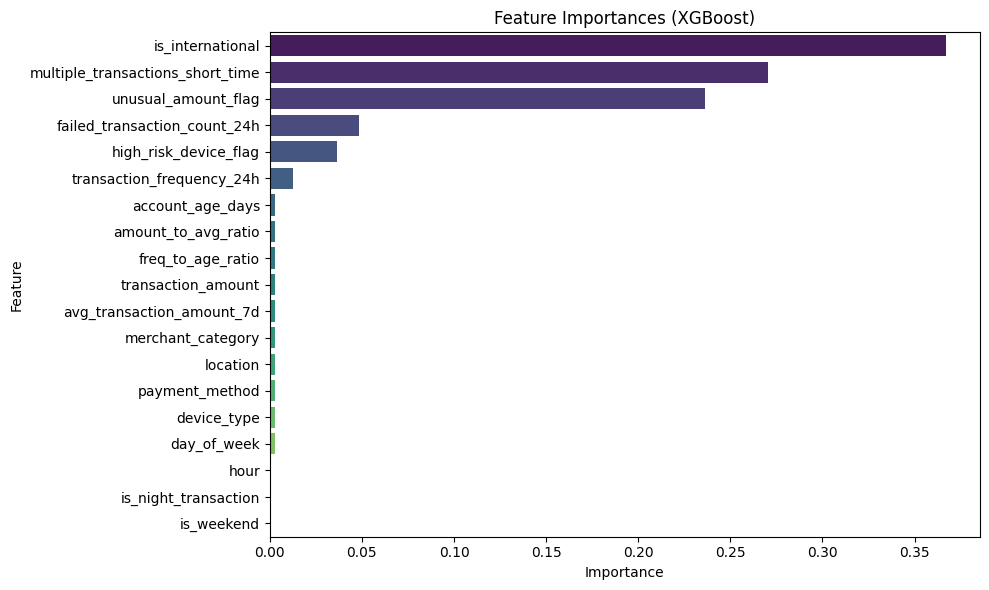


🗑️ ویژگی‌های نویز که حذف می‌شوند: ['day_of_week', 'hour', 'is_night_transaction', 'is_weekend']
⚙️ در حال آموزش Stacking روی ویژگی‌های منتخب (لطفا کمی صبر کنید)...

📁 در حال ساخت فایل‌های نهایی Feature Selection...
✅ ذخیره شد: output\Final_FS_Stacking_th_0.19.csv
✅ ذخیره شد: output\Final_FS_Stacking_th_0.22.csv
✅ ذخیره شد: output\Final_FS_Stacking_th_0.25.csv
✅ ذخیره شد: output\Final_FS_Stacking_th_0.28.csv
✅ ذخیره شد: output\Final_FS_Stacking_th_0.30.csv

🎉 کار تمام شد! فایل‌های بدون نویز در پوشه output آماده ارسال هستند.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

print("🔍 در حال محاسبه ارزش و اهمیت هر ویژگی (Feature Importance)...")

# 1. محاسبه اهمیت ویژگی‌ها با استفاده از XGBoost
xgb_fs = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_fs.fit(X_train_full, y_train_full)

# 2. ساخت جدول اهمیت ویژگی‌ها
importances = xgb_fs.feature_importances_
fs_df = pd.DataFrame({'Feature': X_train_full.columns, 'Importance': importances})
fs_df = fs_df.sort_values(by='Importance', ascending=False)

# 3. رسم نمودار اهمیت ویژگی‌ها
plt.figure(figsize=(10, 6))
sns.barplot(data=fs_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# 4. حذف ۴ ویژگی که کمترین اهمیت را دارند (حذف نویز)
bottom_features = fs_df['Feature'].tail(4).tolist()
print(f"\n🗑️ ویژگی‌های نویز که حذف می‌شوند: {bottom_features}")

X_train_fs = X_train_full.drop(columns=bottom_features)
X_test_fs = X_test_full.drop(columns=bottom_features)

# 5. آموزش مجدد مدل Stacking روی داده‌های فیلتر شده (بدون نویز)
print("⚙️ در حال آموزش Stacking روی ویژگی‌های منتخب (لطفا کمی صبر کنید)...")
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)),
    ('hgb', HistGradientBoostingClassifier(random_state=42))
]
meta_model = LogisticRegression()

stacking_fs = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)
stacking_fs.fit(X_train_fs, y_train_full)

# 6. پیش‌بینی و ذخیره با آستانه‌های طلایی شما (0.19 تا 0.30)
os.makedirs('output', exist_ok=True)
y_test_prob_fs = stacking_fs.predict_proba(X_test_fs)[:, 1]

best_thresholds = [0.19, 0.22, 0.25, 0.28, 0.30]

print("\n📁 در حال ساخت فایل‌های نهایی Feature Selection...")
for thresh in best_thresholds:
    y_test_pred = (y_test_prob_fs >= thresh).astype(int)
    filename = f'Final_FS_Stacking_th_{thresh:.2f}.csv'
    filepath = os.path.join('output', filename)
    
    pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filepath, index=False)
    print(f"✅ ذخیره شد: {filepath}")

print("\n🎉 کار تمام شد! فایل‌های بدون نویز در پوشه output آماده ارسال هستند.")

In [ ]:


import os
import pandas as pd

print("⚙️ در حال آموزش مجدد مدل‌های تکی تیون‌شده روی داده‌های بدون نویز (Feature Selected)...")

# بازه طلایی آستانه‌ها که پیدا کرده بودی
fs_thresholds = [0.19, 0.22, 0.25, 0.28, 0.30]
os.makedirs('output', exist_ok=True)

for model_name, model in best_tuned_models.items():
    print(f"\n🚀 آموزش {model_name} روی ویژگی‌های منتخب...")
    
    # 1. بازآموزی مدل روی دیتای خالص (بدون اون ۴ ویژگی نویز)
    model.fit(X_train_fs, y_train_full)
    
    # 2. استخراج احتمالات برای دیتای Test
    y_test_prob_fs = model.predict_proba(X_test_fs)[:, 1]
    
    # 3. ساخت فایل برای هر آستانه
    for thresh in fs_thresholds:
        y_test_pred = (y_test_prob_fs >= thresh).astype(int)
        
        filename = f'Final_FS_Tuned_{model_name}_th_{thresh:.2f}.csv'
        filepath = os.path.join('output', filename)
        
        pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filepath, index=False)
        print(f"✅ ذخیره شد: {filepath}")

print("\n🎉 کار تمام شد! تمام فایل‌های تکی (بدون نویز) در پوشه output ساخته شدند.")

⚙️ در حال آموزش مجدد مدل‌های تکی تیون‌شده روی داده‌های بدون نویز (Feature Selected)...

🚀 آموزش RF روی ویژگی‌های منتخب...
✅ ذخیره شد: output\Final_FS_Tuned_RF_th_0.19.csv
✅ ذخیره شد: output\Final_FS_Tuned_RF_th_0.22.csv
✅ ذخیره شد: output\Final_FS_Tuned_RF_th_0.25.csv
✅ ذخیره شد: output\Final_FS_Tuned_RF_th_0.28.csv
✅ ذخیره شد: output\Final_FS_Tuned_RF_th_0.30.csv

🚀 آموزش XGB روی ویژگی‌های منتخب...
✅ ذخیره شد: output\Final_FS_Tuned_XGB_th_0.19.csv
✅ ذخیره شد: output\Final_FS_Tuned_XGB_th_0.22.csv
✅ ذخیره شد: output\Final_FS_Tuned_XGB_th_0.25.csv
✅ ذخیره شد: output\Final_FS_Tuned_XGB_th_0.28.csv
✅ ذخیره شد: output\Final_FS_Tuned_XGB_th_0.30.csv

🚀 آموزش HGB روی ویژگی‌های منتخب...
✅ ذخیره شد: output\Final_FS_Tuned_HGB_th_0.19.csv
✅ ذخیره شد: output\Final_FS_Tuned_HGB_th_0.22.csv
✅ ذخیره شد: output\Final_FS_Tuned_HGB_th_0.25.csv
✅ ذخیره شد: output\Final_FS_Tuned_HGB_th_0.28.csv
✅ ذخیره شد: output\Final_FS_Tuned_HGB_th_0.30.csv

🎉 کار تمام شد! تمام فایل‌های تکی (بدون نویز) در پوشه output 

In [ ]:
import os
import pandas as pd

print("⚖️ در حال اجرای Weighted Blending (ترکیب وزن‌دار دستی)...")
print("🔄 بازآموزی سریع مدل‌های تیون‌شده روی کل داده‌ها (بدون حذف ویژگی‌ها)...")

# 1. بازآموزی مدل‌ها روی کل داده‌های اصلی (برای جلوگیری از تداخل با مرحله قبل)
for name, model in best_tuned_models.items():
    model.fit(X_train_full, y_train_full)

# 2. استخراج احتمالات دیتای Test برای هر سه مدل
p_rf = best_tuned_models['RF'].predict_proba(X_test_full)[:, 1]
p_xgb = best_tuned_models['XGB'].predict_proba(X_test_full)[:, 1]
p_hgb = best_tuned_models['HGB'].predict_proba(X_test_full)[:, 1]

# 3. تعریف ۳ استراتژی برای وزن‌دهی (RF, XGB, HGB)
# نکته: جمع وزن‌ها همیشه باید 1.0 بشه
weight_combinations = {
    'Blend_A_Balanced': (0.15, 0.40, 0.45),  # متعادل (کمی از هر سه)
    'Blend_B_No_RF':    (0.00, 0.50, 0.50),  # فقط ترکیب دو مدل قوی‌تر (XGB و HGB)
    'Blend_C_HGB_Heavy':(0.05, 0.25, 0.70)   # تمرکز شدید روی HGB که از اول قوی‌تر بود
}

# همون بازه طلایی که خودت کشف کرده بودی رو اینجا استفاده می‌کنیم
thresholds = [0.22, 0.25, 0.28, 0.30]

os.makedirs('output', exist_ok=True)

# 4. ساخت فایل‌های خروجی ترکیب وزن‌دار
print("\n📁 در حال ساخت فایل‌های خروجی...")
for blend_name, (w_rf, w_xgb, w_hgb) in weight_combinations.items():
    
    # فرمول جادویی ترکیب احتمالات
    p_blend = (w_rf * p_rf) + (w_xgb * p_xgb) + (w_hgb * p_hgb)
    
    for thresh in thresholds:
        # اعمال آستانه
        y_test_pred = (p_blend >= thresh).astype(int)
        
        filename = f'Final_{blend_name}_th_{thresh:.2f}.csv'
        filepath = os.path.join('output', filename)
        
        pd.DataFrame({'id': test_ids, 'label': y_test_pred}).to_csv(filepath, index=False)

print("✅ کار تمام شد! تمام فایل‌های Blending در پوشه 'output' ذخیره شدند.")

⚖️ در حال اجرای Weighted Blending (ترکیب وزن‌دار دستی)...
🔄 بازآموزی سریع مدل‌های تیون‌شده روی کل داده‌ها (بدون حذف ویژگی‌ها)...

📁 در حال ساخت فایل‌های خروجی...
✅ کار تمام شد! تمام فایل‌های Blending در پوشه 'output' ذخیره شدند.
